# CAPEX/OPEX database of STES

This jupyter notebook extracts the CAPEX and OPEX data of STES technologies (PTES, TTES, BTES and ATES) from the file: STES_CAPEX_OPEX_database.xlsx and creates two simple CSV-files with the data. The created files are ready to use in the STES project python library.

First import necessary packages:

In [38]:
from dataclasses import dataclass
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
from pathlib import Path

Define functions for water properties:

In [39]:
def density_water(T):
    '''Density (rho) of water in kg/m^3 based on fluid temperature (T) nearest the flow meter in degrees Celsius (https://github.com/PitStorages/DronninglundData)'''
    rho = (999.85+5.332*(10**-2)*T-7.564*(10**-3)*(T**2)+4.323*(10**-5)*(T**3)-1.673*(10**-7)*(T**4)+2.447*(10**-10)*(T**5))
    return(rho)

def specific_heat_water(T):
    '''Specific heat (cp) of water in J/(kg K) based on mean fluid temperature (T) in degrees Celsius (https://github.com/PitStorages/DronninglundData)'''
    cp = (4.2184-2.8218*(10**-3)*T+7.3478*(10**-5)*(T**2)-9.4712*(10**-7)*(T**3)+7.2869*(10**-9)*(T**4)-2.8098*(10**-11)*(T**5)
          +4.4008*(10**-14)*(T**6))*1000
    return(cp)

Define STES technologies, for which cost data is given:

In [40]:
@dataclass(frozen=True)
class TechnologyConfig:
    """
    Immutable schema defining the technical boundaries, capacity limits, and Excel 
    data mapping structures for seasonal thermal energy storage (STES) technologies.
    """
    opex_column: str                    # Excel column letter containing Operational Expenditure data
    capex_volume_column: str | None = None # Excel column letter for Volume-based Capital Expenditure
    capex_length_column: str | None = None # Excel column letter for Length-based Capital Expenditure (e.g., boreholes/wells)
    energy_density: float | None = None # Volumetric energy density capacity metric [MWh/m³]
    min_length: float | None = None     # Minimum physical drill depth / structural layout constraint [m]
    max_length: float | None = None     # Maximum physical drill depth / structural layout constraint [m]
    min_capacity: float | None = None   # Lower operational boundary constraint for system sizing [MWh]
    max_capacity: float | None = None   # Upper operational boundary constraint for system sizing [MWh]

# ==============================================================================
# GLOBAL STES TECHNOLOGY REGISTRY
# ==============================================================================
# Central dictionary holding empirical scaling boundaries and import definitions
# for Pit (PTES), Tank (TTES), Borehole (BTES), and Aquifer (ATES) thermal storage.

TECHNOLOGIES = {
    "PTES": TechnologyConfig(
        opex_column="M",
        capex_volume_column="X",
        energy_density=0.070,
        min_capacity=800,
        max_capacity=210000,
    ),
    "TTES": TechnologyConfig(
        opex_column="N",
        capex_volume_column="Y",
        energy_density=0.070,
        min_capacity=200,
        max_capacity=121100,
    ),
    "BTES": TechnologyConfig(
        opex_column="O",
        capex_volume_column="Z",
        capex_length_column="X",
        energy_density=0.023,
        min_length=100,
        max_length=200000,
        min_capacity=5000,
        max_capacity=323000,
    ),
    "ATES": TechnologyConfig(
        opex_column="P",
        capex_volume_column="AA",
        capex_length_column="Y",
        energy_density=0.035,
        min_length=20,
        max_length=3000,
        min_capacity=5266,
        max_capacity=540000,
    ),
}

function to access the OPEX value of the different technologies:

In [41]:
def OPEX_STES(technology):
    """
    Extracts the operational expenditure (OPEX) factor for a specified STES technology
    from the global database spreadsheet.

    Parameters
    ----------
    technology : str
        Key identifier matching the dynamic TECHNOLOGIES registry dictionary 
        (e.g., 'PTES', 'TTES', 'BTES', 'ATES').

    Returns
    -------
    float
        The raw baseline OPEX factor extracted directly from the isolated database cell.
    """
    
    if technology not in TECHNOLOGIES:
        raise ValueError(
            "Invalid technology. Please choose from "
            "'PTES', 'TTES', 'BTES', or 'ATES'."
        )

    config = TECHNOLOGIES[technology]

    OPEX = pd.read_excel(
        "STES_CAPEX_OPEX_database.xlsx",
        sheet_name="OPEX",
        usecols=config.opex_column, # Dynamically grab column letter (e.g., "M", "N")
        skiprows=24,                # Jump directly to the relevant row index offset
        nrows=1,                    # Read exactly 1 row slice containing the scaler
    ).to_numpy()                    # Convert the slice from a Pandas DataFrame to a 2D NumPy array

    return OPEX[0, 0] # Format conversion: return the single scalar value from the 2D array

Example of CAPEX data:

In [42]:
def CAPEX_STES(
    technology="PTES",
    unit="per_volume",
    capacity=10000,
    T_min=None,
    T_max=None,
    plot=False
):
    """
    Computes Capital Expenditure (CAPEX) scaling profiles for STES systems using 
    a log-log power-law regression fit from database points. Also performs a 
    piecewise linear interpolation and tracks its approximation error.

    Parameters
    ----------
    technology : str
        Key matching the global TECHNOLOGIES dictionary registry.
    unit : str
        Pricing index driver: 'per_volume' [m³], 'per_energy' [MWh], or 'per_borehole_length' [m].
    capacity : float
        Target design capacity size to evaluate.
    T_min, T_max : float, optional
        Operational temperature bounds to dynamically establish water-based energy densities.
    plot : bool
        Generates and saves diagnostic validation curve overlays.

    Returns
    -------
    tuple or float
        Depending on whether `capacity` is 0, returns either the linear segment arrays 
        or the target interpolated CAPEX value alongside them.
    """
    
    # --------------------------------------------------------------------------
    # 1. INITIAL CONFIGURATION & SCHEMA VALIDATION
    # --------------------------------------------------------------------------
    if technology not in TECHNOLOGIES:
        raise ValueError("Invalid technology.")

    config = TECHNOLOGIES[technology]

    # Initialize sizing limits default bounds
    min_capacity = config.min_capacity
    max_capacity = config.max_capacity

    # --------------------------------------------------------------------------
    # 2. DEFINE EXCEL EXTRACTION RANGE BASED ON DESIGN UNIT SELECTION
    # --------------------------------------------------------------------------
    if unit in ("per_volume", "per_energy"):
        if config.capex_volume_column is None:
            raise ValueError(f"{technology} does not support unit '{unit}'.")
        rows = 129
        column = config.capex_volume_column
        n = 31
        energy_density = config.energy_density

    elif unit == "per_borehole_length":
        if config.capex_length_column is None:
            raise ValueError(f"{technology} does not support unit '{unit}'.")
        rows = 174
        column = config.capex_length_column
        n = 29
        # Overwrite volume boundaries with length-based boundaries [m]
        min_capacity = config.min_length
        max_capacity = config.max_length

    else:
        raise ValueError("Invalid unit.")

    # --------------------------------------------------------------------------
    # 3. DIRECT RAW SHEET FETCH
    # --------------------------------------------------------------------------
    # Extract structural pricing metrics
    CAPEX_data = pd.read_excel(
        "STES_CAPEX_OPEX_database.xlsx",
        sheet_name="CAPEX",
        usecols=column,
        skiprows=rows,
        nrows=n
    ).to_numpy()

    # Extract matching physical sizing/capacity parameters
    capacity_data = pd.read_excel(
        "STES_CAPEX_OPEX_database.xlsx",
        sheet_name="CAPEX",
        usecols="B",
        skiprows=rows,
        nrows=n
    ).to_numpy()

    # --------------------------------------------------------------------------
    # 4. THERMODYNAMIC STEP-UP: ENERGY CAPACITY CONVERSIONS
    # --------------------------------------------------------------------------
    if unit == "per_energy":
        if energy_density is None:
            raise ValueError(f"{technology} does not support 'per_energy'.")

        # Dynamic volumetric calculation using water property utilities if bounds are provided
        if T_min is not None and T_max is not None:
            # ΔT * cp * rho / scaling factor -> MWh/m³
            energy_density = ((T_max - T_min) * 
                              specific_heat_water((T_max + T_min) / 2) * 
                              density_water((T_max + T_min) / 2) / 3.6e9)
        
        # Convert target capacity input from Energy [MWh] to physical Volume [m³]
        capacity /= energy_density if energy_density != 0 else 0

    # --------------------------------------------------------------------------
    # 5. MATHEMATICAL MODELING: POWER-LAW REGRESSION (y = a * x^b)
    # --------------------------------------------------------------------------
    flat_capacity = capacity_data.flatten()
    flat_capex = CAPEX_data.flatten()
    
    # Filter out empty or non-physical zero cells to prevent log(0) runtime faults
    valid_idx = (flat_capacity > 0) & (flat_capex > 0)
    valid_capacity = flat_capacity[valid_idx]
    valid_capex = flat_capex[valid_idx]

    # Transform data into log-log space to linearize the power law equation:
    # log10(y) = b * log10(x) + log10(a)
    log_x = np.log10(valid_capacity)
    log_y = np.log10(valid_capex)

    # Perform a 1st-degree linear polynomial fit over the transformed logs
    b, log10_a = np.polyfit(log_x, log_y, 1)

    # Convert structural intercept back into original linear scaling parameter 'a'
    a = 10 ** log10_a

    # Standard power-law curve definition model
    def cost_curve(x, a, b):
        return a * x ** b

    # --------------------------------------------------------------------------
    # 6. PIECEWISE LINEAR APPROXIMATION SETUP & ERROR EVALUATION
    # --------------------------------------------------------------------------
    # Generate 7 log-spaced capacity breakpoint markers across full operating boundaries
    capacity_lin = np.logspace(np.log10(min_capacity), np.log10(max_capacity), 7)
    CAPEX_lin = cost_curve(capacity_lin, a, b)

    # Create a dense grid to precisely calculate interpolation degradation errors
    x_error = np.logspace(np.log10(min_capacity), np.log10(max_capacity), 10000)

    # Compute true regression curve versus standard linear interp outputs
    y_true = cost_curve(x_error, a, b)
    y_linear = np.interp(x_error, capacity_lin, CAPEX_lin)

    # Calculate worst-case localized relative percentage error
    error = np.abs(y_true - y_linear)
    max_relative_error = np.max(error / y_true) * 100

    # Evaluate specific design point; return zero if capacity input equals zero
    CAPEX = np.interp(capacity, capacity_lin, CAPEX_lin) if capacity != 0 else 0

    # --------------------------------------------------------------------------
    # 7. SCALE ARRAYS BACK TO ENERGY UNITS (IF APPLICABLE)
    # --------------------------------------------------------------------------
    if unit == "per_energy":
        capacity *= energy_density
        CAPEX /= energy_density
        capacity_lin *= energy_density
        CAPEX_lin /= energy_density
        min_capacity *= energy_density
        max_capacity *= energy_density

    # Generate visual continuous lines array maps
    x = np.linspace(min_capacity, max_capacity, 100)
    y = (cost_curve(x / energy_density, a, b) / energy_density 
         if unit == "per_energy" else cost_curve(x, a, b))

    # --------------------------------------------------------------------------
    # 8. EXPORT DIAGNOSTIC REPORT GRAPHICS
    # --------------------------------------------------------------------------
    if plot:
        plt.scatter(capacity_lin, CAPEX_lin, color="#C04F15")
        plt.plot(x, y, color="#C04F15", label="fitted curve")
        plt.plot(capacity_lin, CAPEX_lin, color="#C04F15", linestyle="--", alpha=0.7, label="linear segments")
        
        if capacity != 0: 
            plt.scatter(capacity, CAPEX, color="#C04F15", marker="x", label="interpolated point")
        
        plt.plot(capacity_data, CAPEX_data, color="#C04F15", linestyle="-.", alpha=0.7, label="import data")
        plt.title("CAPEX curve", fontsize=18)    
        plt.xlabel("capacity", fontsize=14)
        plt.ylabel("CAPEX / capacity", fontsize=14)
        plt.xticks([]) # Hide coordinate values for generic layout presentation
        plt.yticks([]) 
        plt.legend(fontsize=12)
        
        # High-res save directly into the LaTeX documentation working directories
        plt.savefig(r"C:\Users\mbkka\Documents\ETHZ\semester_projekt\03_report\capex_plot.png", dpi=1000, bbox_inches='tight')
        plt.show()

        print(f"Maximum relative error: {max_relative_error:.2f}%")

    # --------------------------------------------------------------------------
    # 9. DYNAMIC RETURN PACKAGING
    # --------------------------------------------------------------------------
    if capacity == 0:
        return capacity_lin, CAPEX_lin
    else:
        return CAPEX, capacity_lin, CAPEX_lin

Example of loaded CAPEX curve:

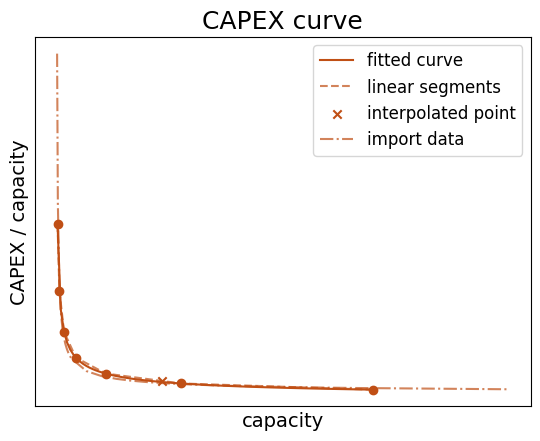

Maximum relative error: 8.50%


(np.float64(64.60147083926708),
 array([   800.        ,   2024.31552085,   5122.31665995,  12961.48139682,
         32797.659956  ,  82991.01512068, 210000.        ]),
 array([600.19745913, 373.24030552, 232.10415763, 144.33687679,
         89.75769419,  55.81694606,  34.71046684]))

In [43]:
CAPEX_STES(technology="PTES", unit="per_volume", capacity=70000, T_min=20, T_max=80, plot=True)

Now the data are stored two CSV-files for easy access of CAPEX and OPEX in other projects. OPEX is saved as a percentage of the CAPEX for each technology. CAPEX is saved as interpolation points of the cost function for each technology. There are different options for the unit of the capacity (e.g. CAPEX/storage volume, CAPEX/maximal storable energy).

In [44]:
# ==============================================================================
# 1. EXTRACT OPERATIONAL EXPENDITURE (OPEX) SCALARS
# ==============================================================================
# Retrieve baseline OPEX coefficients for all 4 primary technology types
OPEX_PTES = OPEX_STES("PTES")
OPEX_TTES = OPEX_STES("TTES")
OPEX_BTES = OPEX_STES("BTES")
OPEX_ATES = OPEX_STES("ATES")

# ==============================================================================
# 2. EXTRACT VOLUMETRIC CAPITAL EXPENDITURE (CAPEX) CURVES
# ==============================================================================
# Passing capacity=0 triggers the fallback return block: (capacity_lin, CAPEX_lin).
# This extracts the 7 log-spaced breakpoints used to build the cost curves.
volume_PTES, CAPEX_PTES_per_volume = CAPEX_STES("PTES", "per_volume", 0)
volume_TTES, CAPEX_TTES_per_volume = CAPEX_STES("TTES", "per_volume", 0)
volume_BTES, CAPEX_BTES_per_volume = CAPEX_STES("BTES", "per_volume", 0)
volume_ATES, CAPEX_ATES_per_volume = CAPEX_STES("ATES", "per_volume", 0)

# ==============================================================================
# 3. EXTRACT GEOLOGICAL LENGTH-BASED CAPEX CURVES (BTES & ATES)
# ==============================================================================
# For borehole and well depths, we run the function using length-based indexing.
# Index [0] yields the length segment grid; index [1] yields the matching CAPEX curves.
CAPEX_BTES_per_borehole_length = CAPEX_STES("BTES", "per_borehole_length", 0)[1]
CAPEX_ATES_per_borehole_length = CAPEX_STES("ATES", "per_borehole_length", 0)[1]
BTES_borehole_length = CAPEX_STES("BTES", "per_borehole_length", 0)[0]
ATES_borehole_length = CAPEX_STES("ATES", "per_borehole_length", 0)[0]

# ==============================================================================
# 4. STRUCTURE DATA INTO PANDAS DATAFRAMES
# ==============================================================================
# OPEX Dataframe: Stores simple flat scalar constants (requires explicit single index)
OPEX_DATA = pd.DataFrame({
    'OPEX_PTES': OPEX_PTES,
    'OPEX_TTES': OPEX_TTES,
    'OPEX_BTES': OPEX_BTES,
    'OPEX_ATES': OPEX_ATES
}, index=[0])

# CAPEX Dataframe: Maps the vector arrays together.
# Each entry contains a 7-element array corresponding to our linear piecewise segments.
CAPEX_DATA = pd.DataFrame({
    'volume_PTES': volume_PTES,
    'volume_TTES': volume_TTES,
    'volume_BTES': volume_BTES,
    'volume_ATES': volume_ATES,
    'CAPEX_PTES_per_volume': CAPEX_PTES_per_volume,
    'CAPEX_TTES_per_volume': CAPEX_TTES_per_volume,
    'CAPEX_BTES_per_volume': CAPEX_BTES_per_volume,
    'CAPEX_ATES_per_volume': CAPEX_ATES_per_volume,
    'BTES_borehole_length': BTES_borehole_length,
    'CAPEX_BTES_per_borehole_length': CAPEX_BTES_per_borehole_length,
    'ATES_borehole_length': ATES_borehole_length,
    'CAPEX_ATES_per_borehole_length': CAPEX_ATES_per_borehole_length
})

# ==============================================================================
# 5. FILE EXPORT
# ==============================================================================

# define path for saving the data
BASE_DIR = Path.cwd().parent
OPEX_DATA_PATH = BASE_DIR / "src" / "stes_tools" / "data" / "STES_OPEX_data.csv"
CAPEX_DATA_PATH = BASE_DIR / "src" / "stes_tools" / "data" / "STES_CAPEX_data.csv"

# Save matrices to CSV flat files for direct ingestion by optimization models or LaTeX
OPEX_DATA.to_csv(OPEX_DATA_PATH, index=False)
CAPEX_DATA.to_csv(CAPEX_DATA_PATH, index=False)

Below the usage of the CAPEX function from the STES project python library is shown:

In [ ]:
import stes_tools as st

CAPEX = st.CAPEX_STES('PTES', 'per_volume', 70000, T_min=45, T_max=85) #* 70000
OPEX = CAPEX * st.OPEX_STES('PTES')
print("CAPEX of a PTES with a volume of 70000 m^3 and temperature range from 45°C to 85°C:", round(CAPEX), "CHF, OPEX of the same PTES:", round(OPEX), "CHF/a")


CAPEX of a PTES with a volume of 70000 m^3 and temperature range from 45°C to 85°C: 65 CHF, OPEX of the same PTES: 1 CHF/a
